# YOLO Dataset Creation & Training

**2-class model** — `person` (0) and `ball` (1). Role assignment (team A/B, goalkeeper, referee) is handled in post-processing.

600 annotated frames across 6 matches — 480 train / 120 val.

In [1]:
import sys
import importlib
import torch
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

import src.dataset
importlib.reload(src.dataset)

from src.config import Config
from src.dataset import create_data_yaml, split_val, visualize_labels

dataset_dir = Config.PROJECT_ROOT / "dataset"
train_imgs = len(list((dataset_dir / "images" / "train").glob("*.jpg")))
val_imgs = len(list((dataset_dir / "images" / "val").glob("*.jpg"))) if (dataset_dir / "images" / "val").exists() else 0
print(f"Dataset: {dataset_dir}")
print(f"  Total: {train_imgs + val_imgs} frames ({train_imgs} train, {val_imgs} val)")
if torch.cuda.is_available():
    cc_major, cc_minor = torch.cuda.get_device_capability(0)
    device_arch = f"sm_{cc_major}{cc_minor}"
    supported_arches = set(torch.cuda.get_arch_list())
    gpu_name = torch.cuda.get_device_name(0)
    print(f"CUDA: enabled ({gpu_name})")
    if device_arch in supported_arches:
        print(f"PyTorch CUDA arch support: OK ({device_arch})")
    else:
        print(f"PyTorch CUDA arch support: MISSING ({device_arch})")
        print("Install a newer PyTorch build (CUDA 12.8/13.0) to use GPU for training.")
else:
    print("CUDA: not available (training will use CPU)")

Dataset: C:\Users\PC\Desktop\GitHub\football-computer-vision\dataset
  Total: 971 frames (822 train, 149 val)
CUDA: enabled (NVIDIA GeForce RTX 5070)
PyTorch CUDA arch support: OK (sm_120)


## Train

In [2]:
import os, torch
from ultralytics import YOLO
from src.config import Config
from src.dataset import split_val, create_data_yaml

dataset_dir = Config.PROJECT_ROOT / "dataset"

create_data_yaml(dataset_dir)
split_val(dataset_dir)

for cache in (dataset_dir / "labels").rglob("*.cache"):
    cache.unlink()
    print(f"Deleted stale cache: {cache.name}")

# ── Training setup ───────────────────────────────────────────────────────────
torch.backends.cudnn.benchmark = True
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

use_cuda = False
if torch.cuda.is_available():
    cc_major, cc_minor = torch.cuda.get_device_capability(0)
    if f"sm_{cc_major}{cc_minor}" in set(torch.cuda.get_arch_list()):
        use_cuda = True
device  = 0 if use_cuda else "cpu"
workers = max(2, min(8, os.cpu_count() or 2))

# batch=8 is well-utilised on 12 GB VRAM with yolov8m + imgsz=1280 + AMP.
# autobatch (-1) underestimates peak VRAM when mosaic=1.0 because mosaic
# tiles 4 images per sample, so actual usage is ~4x the clean-forward estimate.
batch = 8 if use_cuda else 2

print(f"Device: {'CUDA' if use_cuda else 'CPU'}")

# ── Model choice ─────────────────────────────────────────────────────────────
# n=3M params (~10 min)  s=11M (~35 min)  m=25M (~60 min)  l=43M (~2 h)
MODEL = "yolov8m.pt"

model = YOLO(MODEL)
model.train(
    data          = str(dataset_dir / "data.yaml"),
    epochs        = 150,
    imgsz         = 1280,
    batch         = batch,
    device        = device,
    workers       = workers,
    mosaic        = 1.0,
    copy_paste    = 0.3,
    cache         = True,
    amp           = use_cuda,
    deterministic = False,
    name          = f"football_2class_{MODEL.replace('.pt', '')}_v2",
    patience      = 30,
)

Created C:\Users\PC\Desktop\GitHub\football-computer-vision\dataset\data.yaml
Split: 822 train, 149 val (from 971 total)
Val matches: mla-bud-2, jed-ars, pet-mor
Deleted stale cache: train.cache
Device: CUDA
New https://pypi.org/project/ultralytics/8.4.36 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.30  Python-3.13.12 torch-2.12.0.dev20260327+cu128 CUDA:0 (NVIDIA GeForce RTX 5070, 12227MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\PC\Desktop\GitHub\football-computer-vision\dataset\data.yaml, degrees=0.0, deterministic=False, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000017DCD98B3F0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0

## Error Analysis — Misclassified & Missed Crops

Run the trained model on **val** images, match predictions to ground-truth via IoU,
and display:
1. **Class confusions** — GT says person but model says ball (or vice-versa)
2. **False positives** — high-confidence detections with no matching GT box
3. **False negatives** — GT boxes the model completely missed

Model: C:\Users\PC\Desktop\GitHub\football-computer-vision\runs\detect\football_2class_yolov8m_v22\weights\best.pt
Val images: 149

Class confusions: 0
False positives:  131 total, 29 ball
False negatives:  61 total, 16 ball

Class Confusions (GT vs Pred): none!


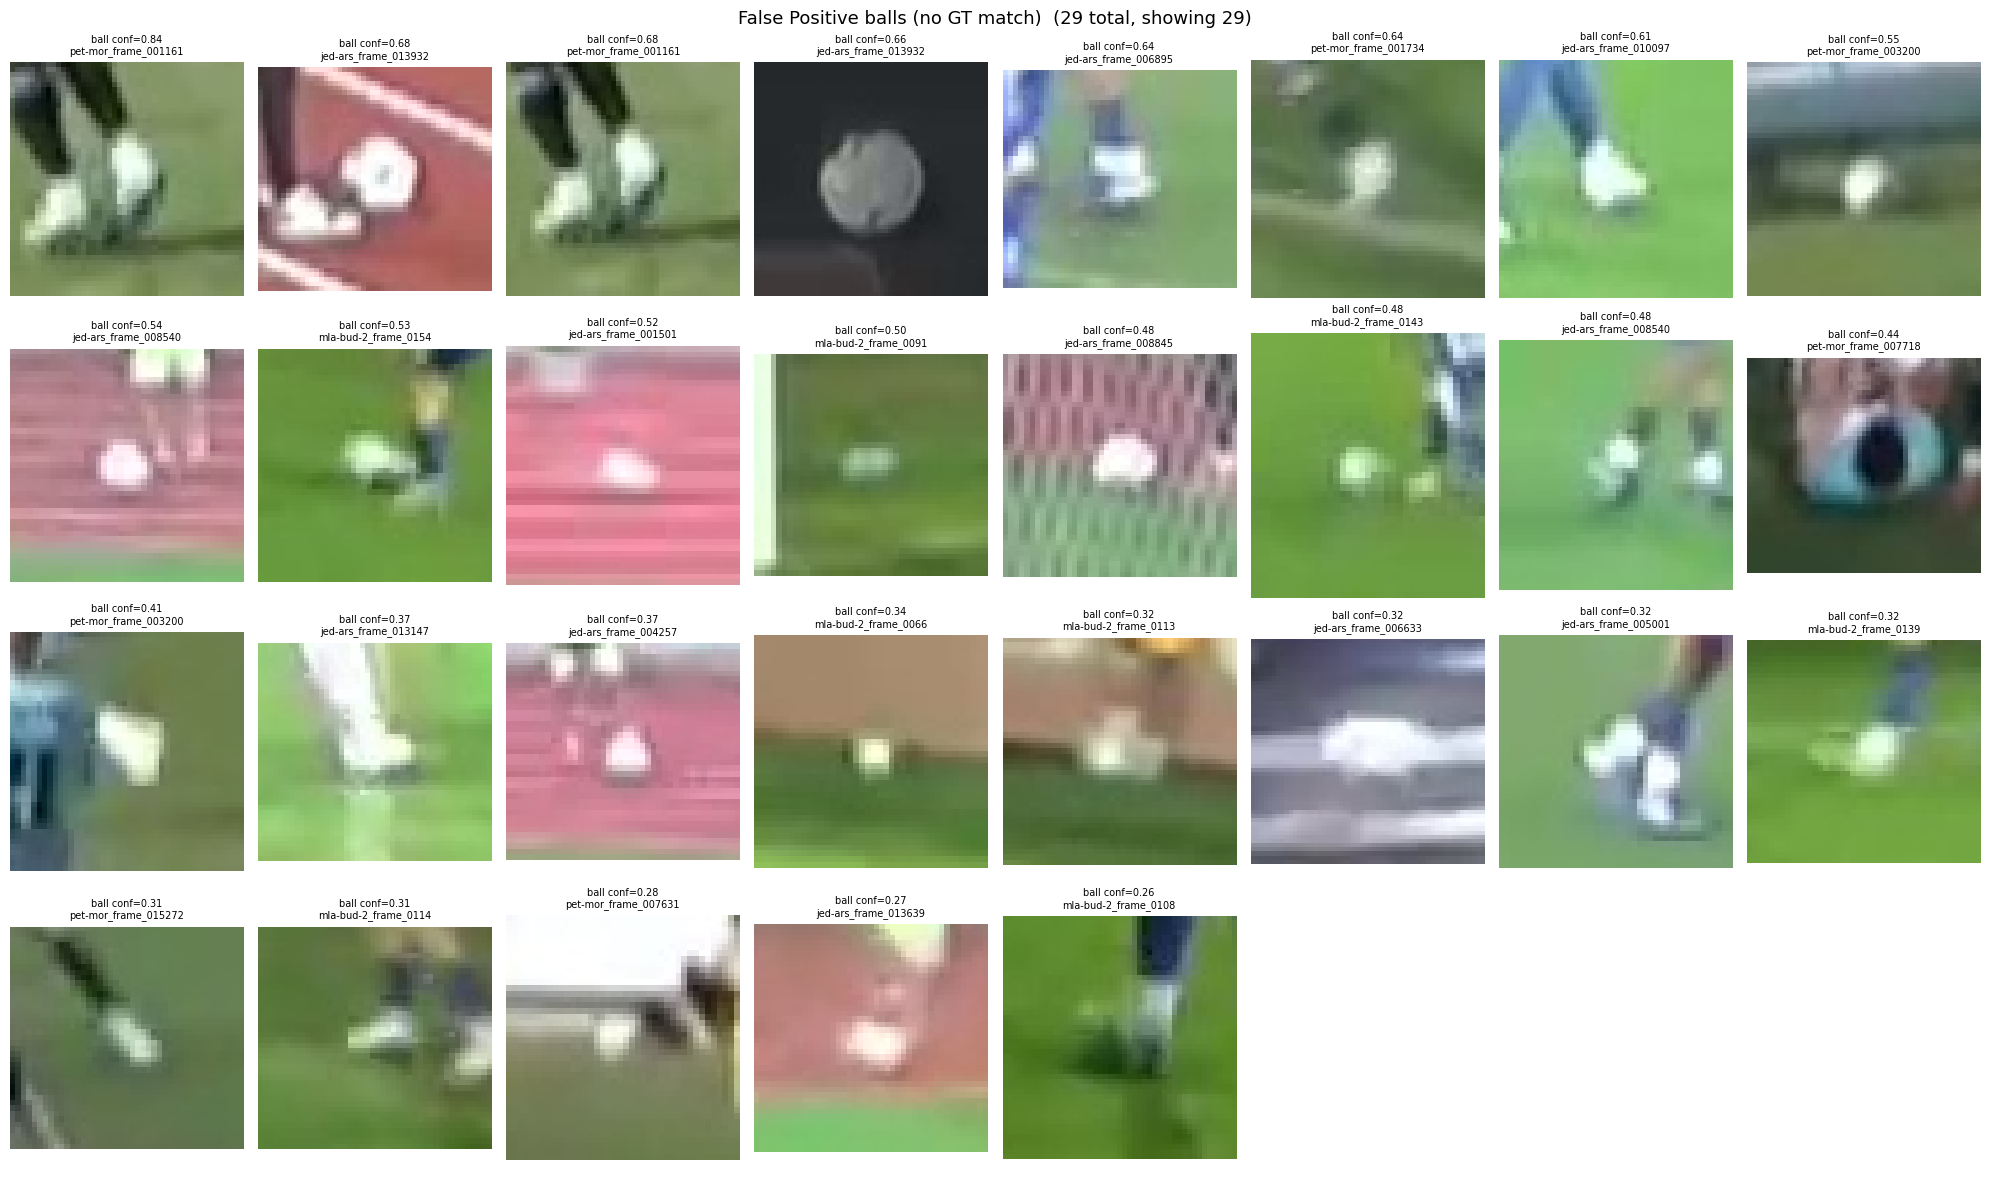

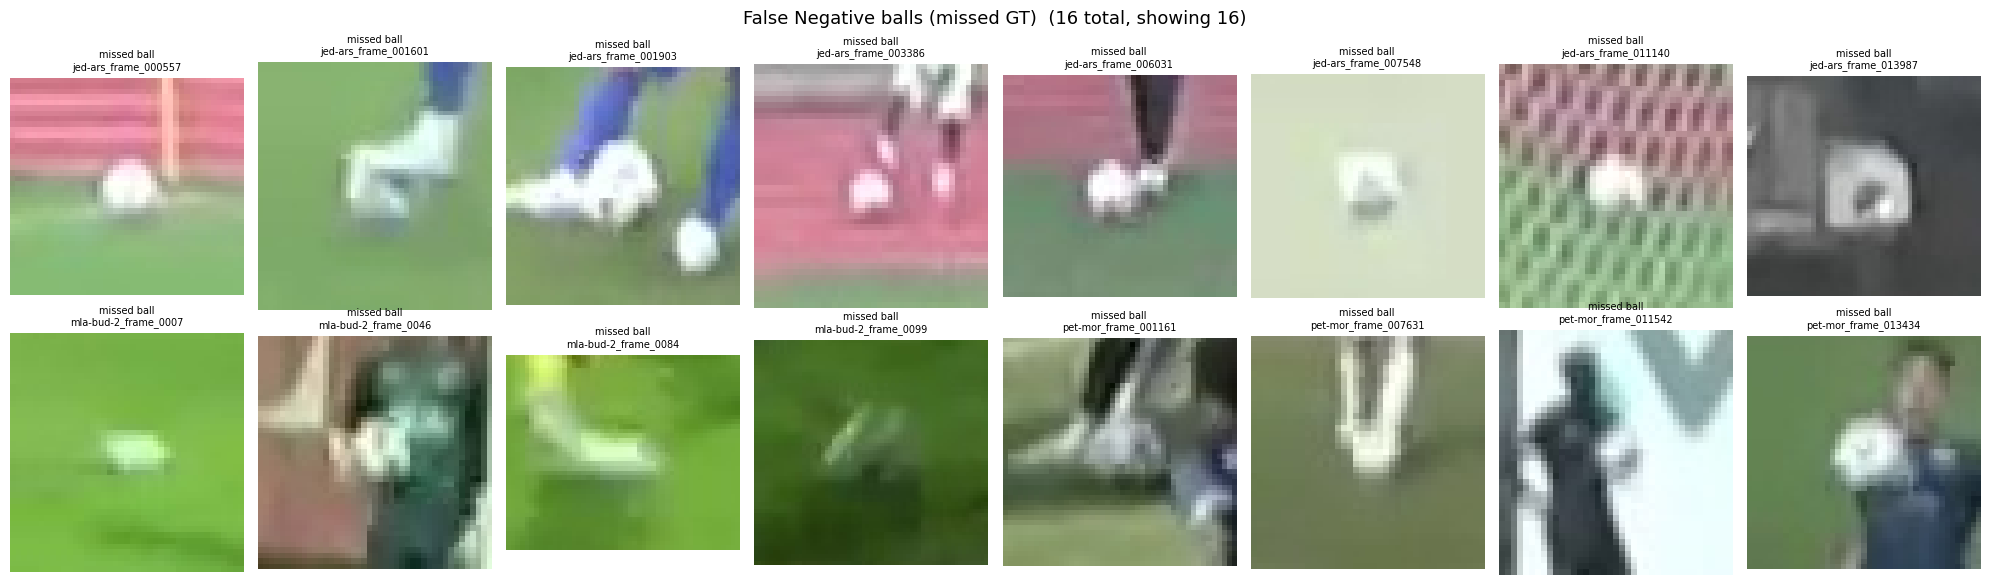

In [1]:
import cv2, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from src.config import Config

# ── Settings ──────────────────────────────────────────────────────────────────
IOU_THRESHOLD = 0.5          # IoU to count as a match
CONF_THRESHOLD = 0.25        # prediction confidence cutoff
PAD = 15                     # pixels of padding around crops
MAX_SHOW = 30                # max crops per category
CLASSES = {0: "person", 1: "ball"}

# Filter: set to None to show all, or 0/1 to show only that class
FP_CLASS_FILTER = 1          # only show false-positive balls
FN_CLASS_FILTER = 1          # only show false-negative balls

# ── Load model & paths ───────────────────────────────────────────────────────
weights = Config.resolve_yolo_model()
print(f"Model: {weights}")
model = YOLO(weights)

dataset_dir = Config.PROJECT_ROOT / "dataset"
val_imgs_dir = dataset_dir / "images" / "val"
val_lbls_dir = dataset_dir / "labels" / "val"
val_images = sorted(val_imgs_dir.glob("*.jpg"))
print(f"Val images: {len(val_images)}")

# ── Helpers ───────────────────────────────────────────────────────────────────
def yolo_to_xyxy(cx, cy, w, h, img_w, img_h):
    x1 = (cx - w / 2) * img_w
    y1 = (cy - h / 2) * img_h
    x2 = (cx + w / 2) * img_w
    y2 = (cy + h / 2) * img_h
    return [x1, y1, x2, y2]

def iou(a, b):
    x1 = max(a[0], b[0]); y1 = max(a[1], b[1])
    x2 = min(a[2], b[2]); y2 = min(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = (a[2]-a[0]) * (a[3]-a[1])
    area_b = (b[2]-b[0]) * (b[3]-b[1])
    return inter / (area_a + area_b - inter + 1e-6)

def crop(img, box):
    h, w = img.shape[:2]
    x1 = max(0, int(box[0]) - PAD)
    y1 = max(0, int(box[1]) - PAD)
    x2 = min(w, int(box[2]) + PAD)
    y2 = min(h, int(box[3]) + PAD)
    return img[y1:y2, x1:x2]

# ── Run inference & collect errors ────────────────────────────────────────────
confusions = []   # (crop, gt_cls, pred_cls, conf, filename)
false_pos  = []   # (crop, pred_cls, conf, filename)
false_neg  = []   # (crop, gt_cls, filename)

for img_path in val_images:
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ih, iw = img.shape[:2]

    # Ground truth
    lbl_path = val_lbls_dir / img_path.with_suffix(".txt").name
    gt_boxes = []
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().splitlines():
            parts = line.split()
            cls = int(parts[0])
            box = yolo_to_xyxy(*map(float, parts[1:5]), iw, ih)
            gt_boxes.append((cls, box))

    # Predictions
    results = model.predict(img_path, conf=CONF_THRESHOLD, verbose=False)
    pred_boxes = []
    for r in results:
        for box in r.boxes:
            cls = int(box.cls[0])
            conf = float(box.conf[0])
            xyxy = box.xyxy[0].cpu().numpy().tolist()
            pred_boxes.append((cls, xyxy, conf))

    # Match preds to GT (greedy by IoU)
    gt_matched = [False] * len(gt_boxes)
    pred_matched = [False] * len(pred_boxes)

    pairs = []
    for pi, (pc, pb, pconf) in enumerate(pred_boxes):
        for gi, (gc, gb) in enumerate(gt_boxes):
            score = iou(pb, gb)
            if score >= IOU_THRESHOLD:
                pairs.append((score, pi, gi))
    pairs.sort(reverse=True)

    for score, pi, gi in pairs:
        if pred_matched[pi] or gt_matched[gi]:
            continue
        pred_matched[pi] = True
        gt_matched[gi] = True
        pc, pb, pconf = pred_boxes[pi]
        gc, gb = gt_boxes[gi]
        if pc != gc:
            confusions.append((crop(img_rgb, pb), gc, pc, pconf, img_path.name))

    for pi, matched in enumerate(pred_matched):
        if not matched:
            pc, pb, pconf = pred_boxes[pi]
            false_pos.append((crop(img_rgb, pb), pc, pconf, img_path.name))

    for gi, matched in enumerate(gt_matched):
        if not matched:
            gc, gb = gt_boxes[gi]
            false_neg.append((crop(img_rgb, gb), gc, img_path.name))

# Apply class filters
fp_filtered = [x for x in false_pos if FP_CLASS_FILTER is None or x[1] == FP_CLASS_FILTER]
fn_filtered = [x for x in false_neg if FN_CLASS_FILTER is None or x[1] == FN_CLASS_FILTER]

fp_filtered.sort(key=lambda x: -x[2])
fn_filtered.sort(key=lambda x: x[2])

fp_label = f"False Positive {CLASSES.get(FP_CLASS_FILTER, 'all')}" if FP_CLASS_FILTER is not None else "False Positives"
fn_label = f"False Negative {CLASSES.get(FN_CLASS_FILTER, 'all')}" if FN_CLASS_FILTER is not None else "False Negatives"

print(f"\nClass confusions: {len(confusions)}")
print(f"False positives:  {len(false_pos)} total, {len(fp_filtered)} {CLASSES.get(FP_CLASS_FILTER, 'all')}")
print(f"False negatives:  {len(false_neg)} total, {len(fn_filtered)} {CLASSES.get(FN_CLASS_FILTER, 'all')}")

# ── Visualization ─────────────────────────────────────────────────────────────
def show_crops(items, title, label_fn):
    if not items:
        print(f"\n{title}: none!")
        return
    n = min(len(items), MAX_SHOW)
    cols = min(8, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(2.5 * cols, 3 * rows))
    fig.suptitle(f"{title}  ({len(items)} total, showing {n})", fontsize=13)
    axes = np.atleast_2d(axes).flatten()
    for i in range(n):
        c = items[i][0]
        if c.size == 0:
            axes[i].axis("off"); continue
        axes[i].imshow(c)
        axes[i].set_title(label_fn(items[i]), fontsize=7)
        axes[i].axis("off")
    for j in range(n, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()

show_crops(confusions, "Class Confusions (GT vs Pred)",
           lambda x: f"GT={CLASSES[x[1]]} Pred={CLASSES[x[2]]}\n{x[3]:.2f} | {x[4][:20]}")

show_crops(fp_filtered, f"{fp_label}s (no GT match)",
           lambda x: f"{CLASSES[x[1]]} conf={x[2]:.2f}\n{x[3][:20]}")

show_crops(fn_filtered, f"{fn_label}s (missed GT)",
           lambda x: f"missed {CLASSES[x[1]]}\n{x[2][:20]}")